In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
import joblib

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
DATASET_PATH = "/content/drive/MyDrive/IITG dataset/cleaned_dataset"
METADATA_PATH = os.path.join(DATASET_PATH, "metadata.csv")

metadata = pd.read_csv(METADATA_PATH)

print("Dataset shape:", metadata.shape)
display(metadata.head())

Dataset shape: (7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [5]:
discharge_df = metadata[
    (metadata["type"] == "discharge") &
    (pd.to_numeric(metadata["Capacity"], errors="coerce").notna())
].copy()

discharge_df["Capacity"] = pd.to_numeric(
    discharge_df["Capacity"], errors="coerce"
)

discharge_df = discharge_df.sort_values(
    ["battery_id", "test_id"]
).reset_index(drop=True)

print("Discharge records:", len(discharge_df))
display(
    discharge_df[
        ["battery_id", "test_id", "Capacity"]
    ].head(10)
)

Discharge records: 2769


,battery_id,test_id,Capacity
0,B0005,1,1.856487
1,B0005,3,1.846327
2,B0005,5,1.835349
3,B0005,7,1.835263
4,B0005,9,1.834646
5,B0005,11,1.835662
6,B0005,13,1.835146
7,B0005,15,1.825757
8,B0005,17,1.824774
9,B0005,19,1.824613


In [6]:
discharge_df["reference_capacity"] = (
    discharge_df.groupby("battery_id")["Capacity"]
    .transform("max")
)

discharge_df["SoH"] = (
    discharge_df["Capacity"] /
    discharge_df["reference_capacity"]
) * 100

print("SoH range:")
print(
    discharge_df["SoH"].min(),
    "to",
    discharge_df["SoH"].max()
)

display(
    discharge_df[
        ["battery_id", "test_id", "Capacity", "reference_capacity", "SoH"]
    ].head(10)
)

SoH range:
0.0 to 100.0


,battery_id,test_id,Capacity,reference_capacity,SoH
0,B0005,1,1.856487,1.856487,100.000000
1,B0005,3,1.846327,1.856487,99.452721
2,B0005,5,1.835349,1.856487,98.861386
3,B0005,7,1.835263,1.856487,98.856718
4,B0005,9,1.834646,1.856487,98.823482
5,B0005,11,1.835662,1.856487,98.878217
6,B0005,13,1.835146,1.856487,98.850449
7,B0005,15,1.825757,1.856487,98.344690
8,B0005,17,1.824774,1.856487,98.291743
9,B0005,19,1.824613,1.856487,98.283094


In [7]:
EOL_SOH_THRESHOLD = 80.0

print("EOL SoH threshold:", EOL_SOH_THRESHOLD, "%")

EOL SoH threshold: 80.0 %


In [8]:
eol_check = (
    discharge_df.groupby("battery_id")["SoH"]
    .min()
    .reset_index(name="minimum_SoH")
)

eol_check["reaches_EOL"] = (
    eol_check["minimum_SoH"] <= EOL_SOH_THRESHOLD
)

print("Batteries reaching EOL:",
      eol_check["reaches_EOL"].sum(),
      "out of",
      len(eol_check))

display(eol_check)

Batteries reaching EOL: 27 out of 34


,battery_id,minimum_SoH,reaches_EOL
0,B0005,69.348842,True
1,B0006,56.689285,True
2,B0007,74.056928,True
3,B0018,72.293702,True
4,B0025,95.608686,False
5,B0026,76.317981,True
6,B0027,97.081395,False
7,B0028,95.149016,False
8,B0029,87.389752,False
9,B0030,87.720026,False


In [9]:
discharge_df["cycle_index"] = (
    discharge_df.groupby("battery_id").cumcount()
)

discharge_df["RUL"] = np.nan

for battery_id in discharge_df["battery_id"].unique():

    battery_data = discharge_df[
        discharge_df["battery_id"] == battery_id
    ]

    eol_cycles = battery_data.loc[
        battery_data["SoH"] <= EOL_SOH_THRESHOLD,
        "cycle_index"
    ]

    if len(eol_cycles) > 0:
        eol_cycle = eol_cycles.iloc[0]

        discharge_df.loc[
            discharge_df["battery_id"] == battery_id,
            "RUL"
        ] = (
            eol_cycle -
            discharge_df.loc[
                discharge_df["battery_id"] == battery_id,
                "cycle_index"
            ]
        )

print("RUL created successfully.")

display(
    discharge_df[
        ["battery_id", "cycle_index", "Capacity", "SoH", "RUL"]
    ].head(15)
)

RUL created successfully.


,battery_id,cycle_index,Capacity,SoH,RUL
0,B0005,0,1.856487,100.000000,100.0
1,B0005,1,1.846327,99.452721,99.0
2,B0005,2,1.835349,98.861386,98.0
3,B0005,3,1.835263,98.856718,97.0
4,B0005,4,1.834646,98.823482,96.0
5,B0005,5,1.835662,98.878217,95.0
6,B0005,6,1.835146,98.850449,94.0
7,B0005,7,1.825757,98.344690,93.0
8,B0005,8,1.824774,98.291743,92.0
9,B0005,9,1.824613,98.283094,91.0


In [10]:
discharge_df["RUL"] = np.nan

for battery_id in discharge_df["battery_id"].unique():

    battery_mask = discharge_df["battery_id"] == battery_id

    battery_data = discharge_df.loc[battery_mask]

    eol_cycles = battery_data.loc[
        battery_data["SoH"] <= EOL_SOH_THRESHOLD,
        "cycle_index"
    ]

    if len(eol_cycles) > 0:

        eol_cycle = eol_cycles.iloc[0]

        rul_values = (
            eol_cycle -
            discharge_df.loc[battery_mask, "cycle_index"]
        ).clip(lower=0)

        discharge_df.loc[battery_mask, "RUL"] = rul_values

print("RUL recalculated successfully.")

display(
    discharge_df[
        ["battery_id", "cycle_index", "SoH", "RUL"]
    ].head(15)
)

RUL recalculated successfully.


,battery_id,cycle_index,SoH,RUL
0,B0005,0,100.000000,100.0
1,B0005,1,99.452721,99.0
2,B0005,2,98.861386,98.0
3,B0005,3,98.856718,97.0
4,B0005,4,98.823482,96.0
5,B0005,5,98.878217,95.0
6,B0005,6,98.850449,94.0
7,B0005,7,98.344690,93.0
8,B0005,8,98.291743,92.0
9,B0005,9,98.283094,91.0


In [11]:
print("Minimum RUL:", discharge_df["RUL"].min())
print("Maximum RUL:", discharge_df["RUL"].max())

print(
    "Negative RUL values:",
    (discharge_df["RUL"] < 0).sum()
)

Minimum RUL: 0.0
Maximum RUL: 123.0
Negative RUL values: 0


In [18]:
SEQUENCE_LENGTH = 10
STRIDE = 1

print("Sequence length:", SEQUENCE_LENGTH)
print("Stride:", STRIDE)

Sequence length: 10
Stride: 1


In [19]:
# Check available cycles for each battery

battery_cycle_counts = (
    discharge_df.groupby("battery_id")
    .size()
    .reset_index(name="num_cycles")
    .sort_values("num_cycles")
)

display(battery_cycle_counts)

print("Total batteries:", len(battery_cycle_counts))

print(
    "Batteries with at least",
    SEQUENCE_LENGTH,
    "cycles:",
    (battery_cycle_counts["num_cycles"] >= SEQUENCE_LENGTH).sum()
)

print(
    "Batteries with fewer than",
    SEQUENCE_LENGTH,
    "cycles:",
    (battery_cycle_counts["num_cycles"] < SEQUENCE_LENGTH).sum()
)

,battery_id,num_cycles
29,B0052,4
27,B0050,21
28,B0051,25
26,B0049,25
7,B0028,28
6,B0027,28
5,B0026,28
4,B0025,28
11,B0032,40
10,B0031,40


Total batteries: 34
Batteries with at least 10 cycles: 33
Batteries with fewer than 10 cycles: 1


In [20]:
# Create feature dataframe

feature_df = discharge_df.copy()

# Sort by battery and cycle
feature_df = feature_df.sort_values(
    ["battery_id", "cycle_index"]
).reset_index(drop=True)

# Calculate cycle progress for each battery
feature_df["cycle_progress"] = (
    feature_df.groupby("battery_id")["cycle_index"]
    .transform(
        lambda x: x / max(x.max(), 1)
    )
)

# Use ambient temperature if available
if "ambient_temperature" in feature_df.columns:

    feature_df["ambient_temperature"] = pd.to_numeric(
        feature_df["ambient_temperature"],
        errors="coerce"
    )

elif "Temperature_measured" in feature_df.columns:

    feature_df["ambient_temperature"] = pd.to_numeric(
        feature_df["Temperature_measured"],
        errors="coerce"
    )

else:

    # If temperature is not present in metadata
    feature_df["ambient_temperature"] = 0.0

# Fill only missing temperature values
feature_df["ambient_temperature"] = (
    feature_df["ambient_temperature"]
    .interpolate()
    .bfill()
    .ffill()
)

print("Feature dataframe created successfully.")

display(
    feature_df[
        [
            "battery_id",
            "test_id",
            "cycle_index",
            "cycle_progress",
            "ambient_temperature",
            "SoH",
            "RUL"
        ]
    ].head(20)
)

Feature dataframe created successfully.


,battery_id,test_id,cycle_index,cycle_progress,ambient_temperature,SoH,RUL
0,B0005,1,0,0.000000,24,100.000000,100.0
1,B0005,3,1,0.005988,24,99.452721,99.0
2,B0005,5,2,0.011976,24,98.861386,98.0
3,B0005,7,3,0.017964,24,98.856718,97.0
4,B0005,9,4,0.023952,24,98.823482,96.0
5,B0005,11,5,0.029940,24,98.878217,95.0
6,B0005,13,6,0.035928,24,98.850449,94.0
7,B0005,15,7,0.041916,24,98.344690,93.0
8,B0005,17,8,0.047904,24,98.291743,92.0
9,B0005,19,9,0.053892,24,98.283094,91.0


In [21]:
# Create chronological train / validation / test split

feature_df = feature_df.sort_values(
    ["battery_id", "test_id"]
).reset_index(drop=True)

feature_df["split"] = ""

for battery_id, group in feature_df.groupby("battery_id"):

    indices = group.index
    n = len(indices)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    feature_df.loc[
        indices[:train_end],
        "split"
    ] = "train"

    feature_df.loc[
        indices[train_end:val_end],
        "split"
    ] = "validation"

    feature_df.loc[
        indices[val_end:],
        "split"
    ] = "test"

print("Split counts:")
print(feature_df["split"].value_counts())

display(
    feature_df[
        ["battery_id", "test_id", "cycle_index", "split"]
    ].head(20)
)

Split counts:
split
train         1921
test           432
validation     416
Name: count, dtype: int64


,battery_id,test_id,cycle_index,split
0,B0005,1,0,train
1,B0005,3,1,train
2,B0005,5,2,train
3,B0005,7,3,train
4,B0005,9,4,train
5,B0005,11,5,train
6,B0005,13,6,train
7,B0005,15,7,train
8,B0005,17,8,train
9,B0005,19,9,train


In [22]:
# Split summary by battery

split_summary = (
    feature_df
    .groupby(["battery_id", "split"])
    .size()
    .unstack(fill_value=0)
)

display(split_summary)

print("\nOverall split counts:")
print(feature_df["split"].value_counts())

split,test,train,validation
battery_id,,,
B0005,26,117,25
B0006,26,117,25
B0007,26,117,25
B0018,20,92,20
B0025,5,19,4
B0026,5,19,4
B0027,5,19,4
B0028,5,19,4
B0029,6,28,6



Overall split counts:
split
train         1921
test           432
validation     416
Name: count, dtype: int64


In [23]:
# Feature scaling

INPUT_FEATURES = [
    "cycle_progress",
    "ambient_temperature"
]

TARGET_FEATURES = [
    "SoH",
    "RUL"
]

scaler = MinMaxScaler()

# Fit scaler only on training data
train_features = feature_df.loc[
    feature_df["split"] == "train",
    INPUT_FEATURES
]

scaler.fit(train_features)

# Transform all data
feature_df[
    [
        "cycle_progress_scaled",
        "ambient_temperature_scaled"
    ]
] = scaler.transform(
    feature_df[INPUT_FEATURES]
)

print("Scaling completed.")
print("Scaler fitted only on training data.")

display(
    feature_df[
        [
            "battery_id",
            "cycle_index",
            "split",
            "cycle_progress_scaled",
            "ambient_temperature_scaled"
        ]
    ].head(10)
)

Scaling completed.
Scaler fitted only on training data.


,battery_id,cycle_index,split,cycle_progress_scaled,ambient_temperature_scaled
0,B0005,0,train,0.000000,0.5
1,B0005,1,train,0.008603,0.5
2,B0005,2,train,0.017205,0.5
3,B0005,3,train,0.025808,0.5
4,B0005,4,train,0.034410,0.5
5,B0005,5,train,0.043013,0.5
6,B0005,6,train,0.051615,0.5
7,B0005,7,train,0.060218,0.5
8,B0005,8,train,0.068820,0.5
9,B0005,9,train,0.077423,0.5


In [24]:
# Create overlapping sequences

FINAL_FEATURES = [
    "cycle_progress_scaled",
    "ambient_temperature_scaled"
]

X_sequences = []
y_soh = []
y_rul = []

sequence_battery_ids = []
sequence_splits = []

for battery_id, battery_data in feature_df.groupby("battery_id"):

    battery_data = battery_data.sort_values(
        "cycle_index"
    ).reset_index(drop=True)

    # Skip only batteries that genuinely have
    # fewer cycles than the required sequence length
    if len(battery_data) < SEQUENCE_LENGTH:
        continue

    for start in range(
        0,
        len(battery_data) - SEQUENCE_LENGTH + 1,
        STRIDE
    ):

        end = start + SEQUENCE_LENGTH

        window = battery_data.iloc[start:end]

        # Target from final cycle
        soh_target = window["SoH"].iloc[-1]
        rul_target = window["RUL"].iloc[-1]

        # Skip sequence only if target is unavailable
        if pd.isna(soh_target) or pd.isna(rul_target):
            continue

        X_sequences.append(
            window[FINAL_FEATURES].values
        )

        y_soh.append(soh_target)
        y_rul.append(rul_target)

        sequence_battery_ids.append(
            battery_id
        )

        sequence_splits.append(
            window["split"].iloc[-1]
        )

# Convert to NumPy arrays
X_sequences = np.array(X_sequences)
y_soh = np.array(y_soh)
y_rul = np.array(y_rul)

sequence_battery_ids = np.array(
    sequence_battery_ids
)

sequence_splits = np.array(
    sequence_splits
)

print("\nFinal sequence dataset created")
print("--------------------------------")

print("Sequence length:", SEQUENCE_LENGTH)
print("Stride:", STRIDE)

print("X shape:", X_sequences.shape)
print("SoH target shape:", y_soh.shape)
print("RUL target shape:", y_rul.shape)

print(
    "Number of batteries:",
    len(np.unique(sequence_battery_ids))
)

print("\nSequence split:")
print(
    pd.Series(sequence_splits).value_counts()
)


Final sequence dataset created
--------------------------------
Sequence length: 10
Stride: 1
X shape: (2287, 10, 2)
SoH target shape: (2287,)
RUL target shape: (2287,)
Number of batteries: 26

Sequence split:
train         1516
test           392
validation     379
Name: count, dtype: int64


In [25]:
# Save processed Dataset Version 1

OUTPUT_PATH = os.path.join(
    DATASET_PATH,
    "processed_dataset_v1"
)

os.makedirs(OUTPUT_PATH, exist_ok=True)

# Convert sequence metadata to arrays
sequence_battery_ids = np.array(sequence_battery_ids)
sequence_splits = np.array(sequence_splits)

# Save processed sequences and targets
np.savez_compressed(
    os.path.join(OUTPUT_PATH, "sequences_v1.npz"),
    X=X_sequences,
    SoH=y_soh,
    RUL=y_rul,
    battery_id=sequence_battery_ids,
    split=sequence_splits
)

# Save scaler
joblib.dump(
    scaler,
    os.path.join(OUTPUT_PATH, "feature_scaler_v1.pkl")
)

# Save processing metadata
processing_info = {
    "version": "Dataset_V1",
    "sequence_length": SEQUENCE_LENGTH,
    "stride": STRIDE,
    "input_features": FINAL_FEATURES,
    "targets": ["SoH", "RUL"],
    "eol_soh_threshold": EOL_SOH_THRESHOLD,
    "random_seed": SEED,
    "split_strategy": "70/15/15 chronological within each battery",
    "number_of_sequences": len(X_sequences),
    "number_of_batteries": len(set(sequence_battery_ids))
}

pd.DataFrame([processing_info]).to_json(
    os.path.join(OUTPUT_PATH, "processing_info_v1.json"),
    orient="records",
    indent=4
)

print("Dataset Version 1 saved successfully.")
print("Saved at:", OUTPUT_PATH)

Dataset Version 1 saved successfully.
Saved at: /content/drive/MyDrive/IITG dataset/cleaned_dataset/processed_dataset_v1


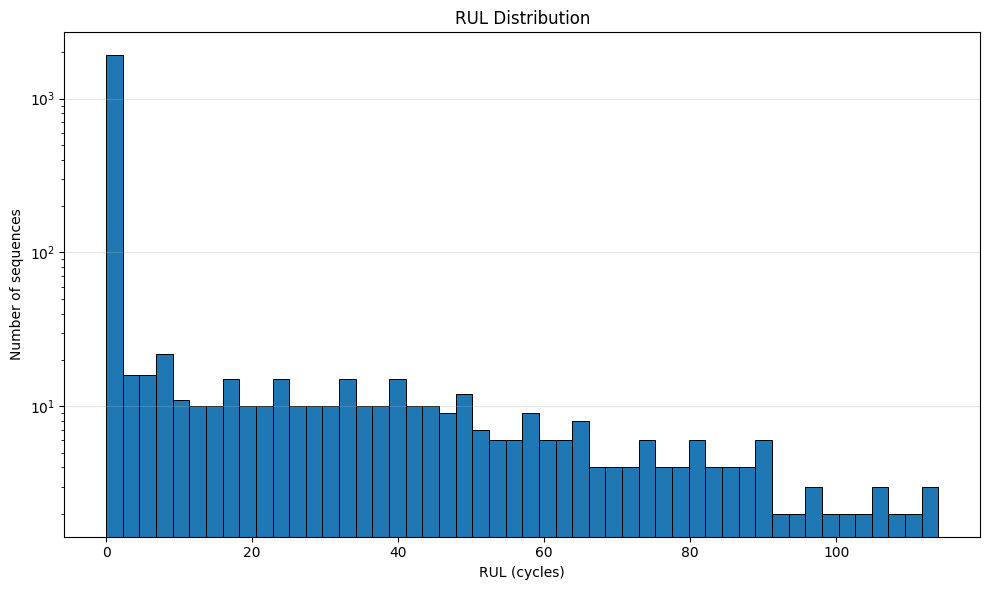

In [26]:
# Final Day 11 check: RUL distribution

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Create more bins for better distribution visibility
bins = np.linspace(
    np.min(y_rul),
    np.max(y_rul),
    51
)

plt.hist(
    y_rul,
    bins=bins,
    edgecolor="black",
    linewidth=0.7
)

plt.xlabel("RUL (cycles)")
plt.ylabel("Number of sequences")
plt.title("RUL Distribution")

# Log scale makes smaller frequency bars visible
plt.yscale("log")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [27]:
# Identify batteries with the lowest and highest RUL coverage

rul_battery_summary = (
    feature_df[feature_df["RUL"].notna()]
    .groupby("battery_id")["RUL"]
    .agg(["min", "max", "count"])
    .sort_values("min")
)

display(rul_battery_summary)

,min,max,count
battery_id,,,
B0005,0.0,100.0,168
B0006,0.0,60.0,168
B0007,0.0,123.0,168
B0018,0.0,74.0,132
B0026,0.0,5.0,28
B0033,0.0,0.0,197
B0034,0.0,0.0,197
B0036,0.0,0.0,197
B0038,0.0,0.0,47
